In [1]:

from src.data_loader import DataLoader
from src.preprocess import Preprocessor


from src.feature_engineering import FeatureEngineer
from src.feature_transformer import FeatureTransformer
from src.feature_selector import FeatureSelector
from src.trainer import Trainer


/Users/plosx/Desktop/machine-learning/modular_programming/project_2/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_loader = DataLoader(path="../data/raw/restaurant_dataset.csv")

In [3]:
data_loader.load()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
x_train, x_test, y_train, y_test = data_loader.split(target_column="aggregate_rating", to_drop=["restaurant_id", "votes", "rating_color", "rating_text"])

In [5]:
prep = Preprocessor()

In [6]:
x_train_filled, x_test_filled = prep.apply_fillna_train_to_test(x_train, x_test)

/Users/plosx/Desktop/machine-learning/modular_programming/project_2/src/preprocess.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(self.fill_values[col], inplace=True)
/Users/plosx/Desktop/machine-learning/modular_programming/project_2/src/preprocess.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

In [7]:
feature_engineer = FeatureEngineer()

In [8]:
x_train_fe = feature_engineer.add_features(x_train_filled)
x_test_fe = feature_engineer.add_features(x_test_filled)

In [9]:
x_train_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7640 entries, 1115 to 7270
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_name       7640 non-null   object 
 1   country_code          7640 non-null   int64  
 2   city                  7640 non-null   object 
 3   address               7640 non-null   object 
 4   locality              7640 non-null   object 
 5   locality_verbose      7640 non-null   object 
 6   longitude             7640 non-null   float64
 7   latitude              7640 non-null   float64
 8   cuisines              7640 non-null   object 
 9   average_cost_for_two  7640 non-null   int64  
 10  currency              7640 non-null   object 
 11  has_table_booking     7640 non-null   object 
 12  has_online_delivery   7640 non-null   object 
 13  is_delivering_now     7640 non-null   object 
 14  switch_to_order_menu  7640 non-null   object 
 15  price_range           7

In [10]:
x_train_encoded, x_test_encoded = prep.apply_encode_train_to_test(x_train_fe, x_test_fe)

In [11]:
ft = FeatureTransformer(skew_threshold=0.5)
x_train_transformed, x_test_transformed = ft.apply_log_transform(x_train_encoded, x_test_encoded)

# Qaysi ustunlar transform qilindi?
print(ft.log_transformed_cols)

['country_code', 'city', 'longitude', 'latitude', 'average_cost_for_two', 'currency', 'has_table_booking', 'has_online_delivery', 'is_delivering_now', 'price_range', 'cost_per_person', 'is_fully_active', 'lat_lon_interaction']


In [12]:
x_train_transformed

,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,cost_per_person,is_fully_active,lat_lon_interaction
1115,5948,0.693147,3.737670,7120,1018,1068,77.306073,28.472912,1188,7.550135,1.609438,0.693147,0.000000,0.0,0,1.386294,6.857514,1.386294,2201.129050
7633,2083,0.693147,4.394449,5598,1002,1052,77.039089,28.621372,703,4.615121,1.609438,0.000000,0.000000,0.0,0,0.693147,3.931826,0.000000,2204.964458
8267,3446,0.693147,4.406719,2523,797,811,77.387116,28.533194,1062,4.615121,1.609438,0.000000,0.000000,0.0,0,0.693147,3.931826,0.000000,2208.101602
7209,669,0.693147,4.394449,5723,874,922,77.282282,28.632808,665,5.525453,1.609438,0.000000,0.000000,0.0,0,0.693147,4.836282,0.000000,2212.808727
6242,1165,0.693147,4.394449,855,706,717,77.135169,28.688001,1278,6.398595,1.609438,0.000000,0.000000,0.0,0,1.098612,5.707110,0.000000,2212.853792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1643,0.693147,4.394449,3641,622,633,0.000000,0.000000,1121,5.303305,1.609438,0.000000,0.000000,0.0,0,0.693147,4.615121,0.000000,0.000000
5191,5406,0.693147,4.394449,5450,568,579,77.206066,28.533123,1278,6.478510,1.609438,0.000000,0.693147,0.0,0,1.098612,5.786897,0.693147,2202.930163
5390,2835,0.693147,4.394449,3817,587,598,77.193738,28.527825,1434,5.525453,1.609438,0.000000,0.000000,0.0,0,0.693147,4.836282,0.000000,2202.169460
860,546,0.693147,3.526361,3417,744,756,78.061187,30.342509,1266,7.378384,1.609438,0.000000,0.000000,0.0,0,1.609438,6.685861,0.000000,2368.572293


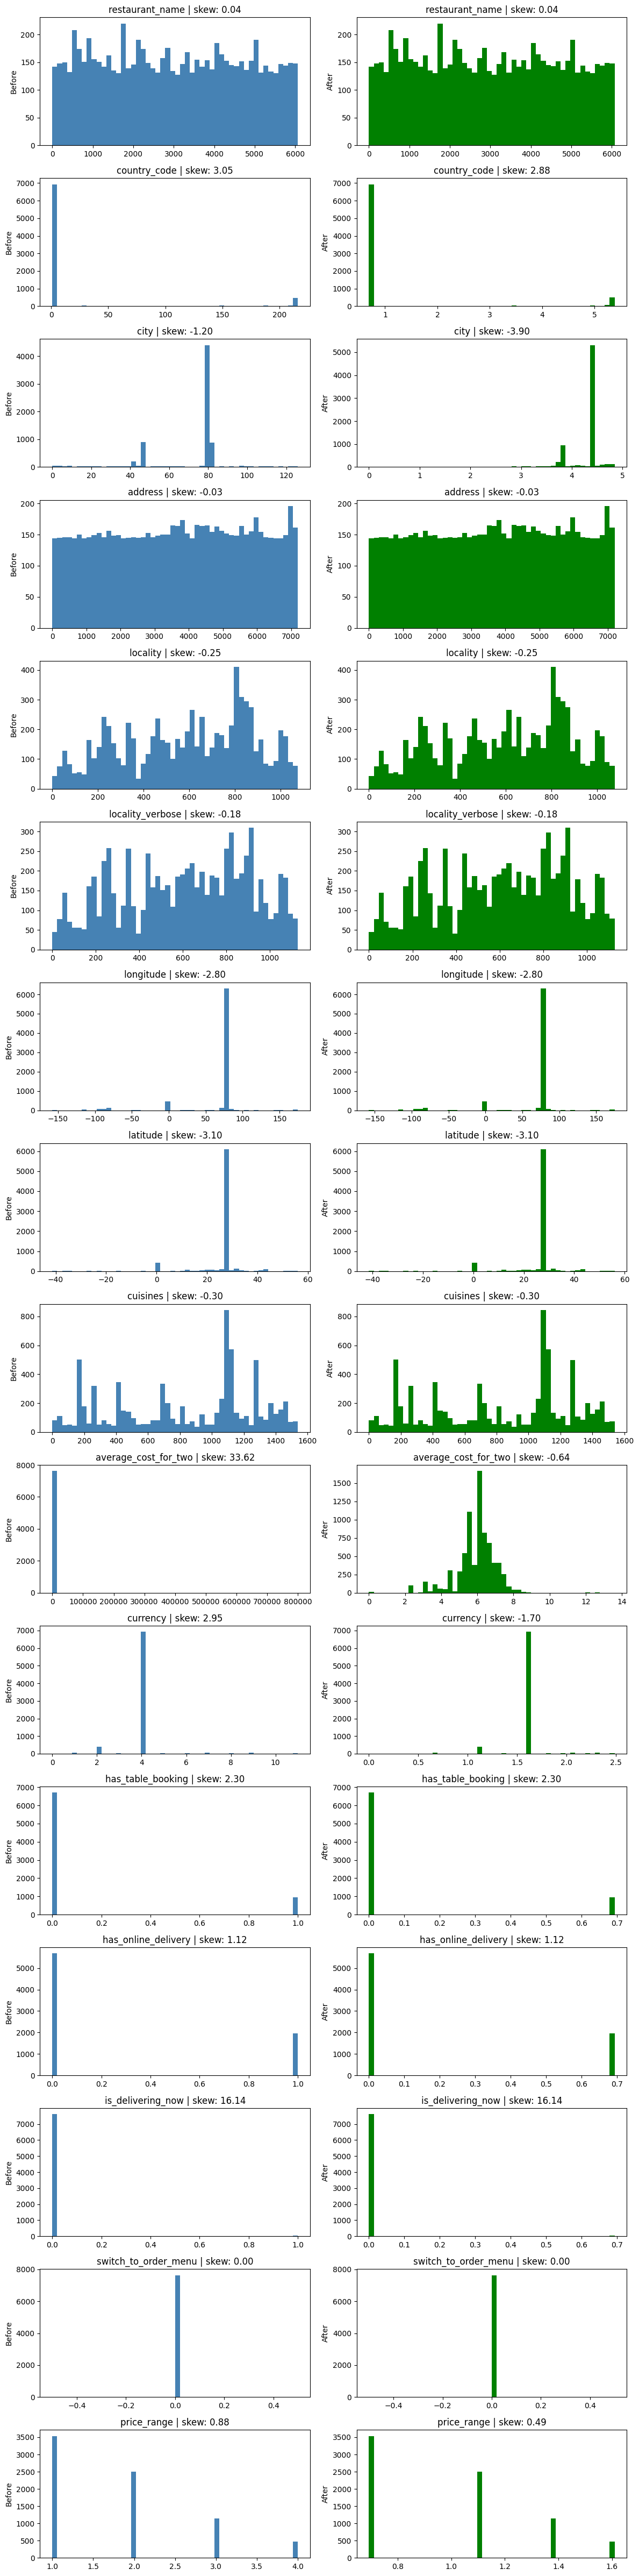

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = x_train.columns

fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(12, len(numeric_cols) * 3))

for i, col in enumerate(numeric_cols):
    # Before
    axes[i, 0].hist(x_train_encoded[col], bins=50, color='steelblue')
    axes[i, 0].set_title(f"{col} | skew: {x_train_encoded[col].skew():.2f}")
    axes[i, 0].set_ylabel("Before")

    # After
    axes[i, 1].hist(x_train_transformed[col], bins=50, color='green')
    axes[i, 1].set_title(f"{col} | skew: {x_train_transformed[col].skew():.2f}")
    axes[i, 1].set_ylabel("After")

plt.tight_layout()
plt.show()

In [14]:
x_test_transformed.head()

,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,cost_per_person,is_fully_active,lat_lon_interaction
4731,5886,0.693147,80,-1,483,489,77.128443,28.651778,1100,5.860786,1.609438,0.0,0.000000,0.0,0,0.693147,5.170484,0.000000,2209.866973
1468,-1,0.693147,46,-1,329,335,77.095432,28.460444,-1,6.552508,1.609438,0.0,0.693147,0.0,0,1.098612,5.860786,0.693147,2194.170253
9037,-1,0.693147,81,-1,907,955,77.340449,28.585474,1278,6.311735,1.609438,0.0,0.000000,0.0,0,1.098612,5.620401,0.000000,2210.813382
7866,-1,0.693147,80,-1,1023,1075,77.201128,28.692000,703,5.303305,1.609438,0.0,0.693147,0.0,0,0.693147,4.615121,0.693147,2215.054741
5570,-1,0.693147,80,-1,611,622,77.216130,28.712062,1278,5.993961,1.609438,0.0,0.000000,0.0,0,0.693147,5.303305,0.000000,2217.034327


In [15]:
x_train_scaled, x_test_scaled = prep.apply_scale_train_to_test(x_train_transformed, x_test_transformed)

In [16]:
x_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7640 entries, 1115 to 7270
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   restaurant_name       7640 non-null   float64
 1   country_code          7640 non-null   float64
 2   city                  7640 non-null   float64
 3   address               7640 non-null   float64
 4   locality              7640 non-null   float64
 5   locality_verbose      7640 non-null   float64
 6   longitude             7640 non-null   float64
 7   latitude              7640 non-null   float64
 8   cuisines              7640 non-null   float64
 9   average_cost_for_two  7640 non-null   float64
 10  currency              7640 non-null   float64
 11  has_table_booking     7640 non-null   float64
 12  has_online_delivery   7640 non-null   float64
 13  is_delivering_now     7640 non-null   float64
 14  switch_to_order_menu  7640 non-null   float64
 15  price_range           7

# Feature Selecting (Correlation Selection)

In [17]:
selector = FeatureSelector()

In [18]:
x_train_selected_cs, x_test_selected_cs = selector.apply_correlation_selection(x_train_scaled, x_test_scaled)

columns removed:  ['locality_verbose', 'cost_per_person']


# Feature Selecting (Feature Importance)

In [19]:
x_train_selected_fi, x_test_selected_fi = selector.apply_importance_selection(x_train_scaled, x_test_scaled, y_train)

                 feature  importance
15           price_range    0.202017
6              longitude    0.108577
3                address    0.099543
0        restaurant_name    0.084281
18   lat_lon_interaction    0.082010
7               latitude    0.077727
8               cuisines    0.077303
9   average_cost_for_two    0.049396
16       cost_per_person    0.047794
4               locality    0.046394
5       locality_verbose    0.046068
12   has_online_delivery    0.029663
17       is_fully_active    0.028081
2                   city    0.018196
11     has_table_booking    0.000973
1           country_code    0.000968
10              currency    0.000935
13     is_delivering_now    0.000075
14  switch_to_order_menu    0.000000
Columns:  ['price_range', 'longitude', 'address', 'restaurant_name', 'lat_lon_interaction', 'latitude', 'cuisines', 'average_cost_for_two', 'cost_per_person', 'locality', 'locality_verbose', 'has_online_delivery', 'is_fully_active', 'city']


In [20]:
x_train_selected_fi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7640 entries, 1115 to 7270
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_range           7640 non-null   float64
 1   longitude             7640 non-null   float64
 2   address               7640 non-null   float64
 3   restaurant_name       7640 non-null   float64
 4   lat_lon_interaction   7640 non-null   float64
 5   latitude              7640 non-null   float64
 6   cuisines              7640 non-null   float64
 7   average_cost_for_two  7640 non-null   float64
 8   cost_per_person       7640 non-null   float64
 9   locality              7640 non-null   float64
 10  locality_verbose      7640 non-null   float64
 11  has_online_delivery   7640 non-null   float64
 12  is_fully_active       7640 non-null   float64
 13  city                  7640 non-null   float64
dtypes: float64(14)
memory usage: 895.3 KB


In [21]:
x_train_selected_fi, x_test_selected_fi = selector.apply_importance_selection(x_train_scaled, x_test_scaled, y_train)

                 feature  importance
15           price_range    0.202017
6              longitude    0.108577
3                address    0.099543
0        restaurant_name    0.084281
18   lat_lon_interaction    0.082010
7               latitude    0.077727
8               cuisines    0.077303
9   average_cost_for_two    0.049396
16       cost_per_person    0.047794
4               locality    0.046394
5       locality_verbose    0.046068
12   has_online_delivery    0.029663
17       is_fully_active    0.028081
2                   city    0.018196
11     has_table_booking    0.000973
1           country_code    0.000968
10              currency    0.000935
13     is_delivering_now    0.000075
14  switch_to_order_menu    0.000000
Columns:  ['price_range', 'longitude', 'address', 'restaurant_name', 'lat_lon_interaction', 'latitude', 'cuisines', 'average_cost_for_two', 'cost_per_person', 'locality', 'locality_verbose', 'has_online_delivery', 'is_fully_active', 'city']


# Feature Selection (RFE)

In [22]:
x_train_selected_rfe, x_test_selected_rfe = selector.apply_rfe_selection(x_train_scaled, x_test_scaled, y_train, n_features=15)

# Training (Linear Regression)(Correlation Selection)

{'model': 'linear_regression', 'version': 'improved', 'r2': -94.0894, 'mae': 13.9632, 'rmse': np.float64(14.7117)}

📊 SHAP Summary — linear_regression


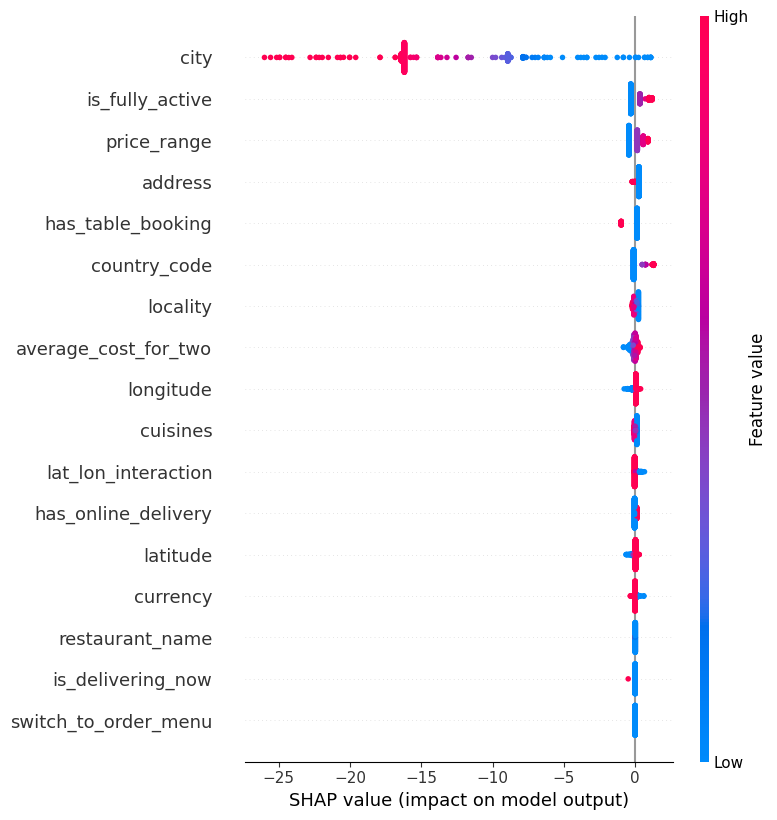

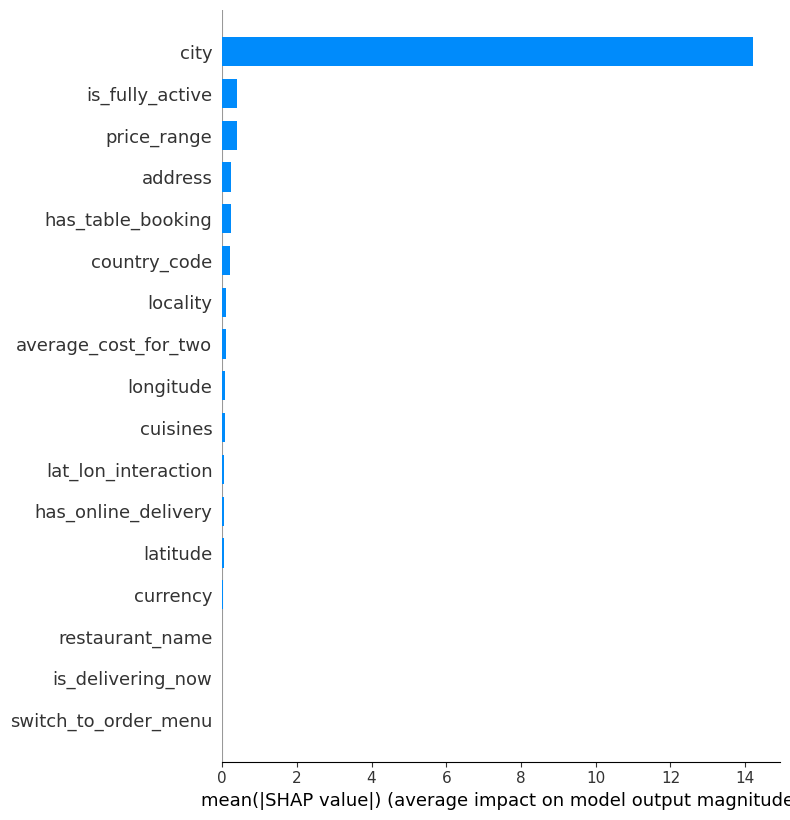

.values =
array([[-9.07527292e-03, -1.05499560e-01, -1.61901049e+01, ...,
        -4.38428138e-01, -3.02224485e-01, -3.51723133e-02],
       [ 9.05685435e-03, -1.05499560e-01, -8.93556692e+00, ...,
         1.49907129e-01,  3.36893946e-01, -3.40200238e-02],
       [ 9.05685435e-03, -1.05499560e-01, -1.64034737e+01, ...,
         1.49907129e-01, -3.02224485e-01, -3.52417887e-02],
       ...,
       [ 9.05685435e-03, -1.05499560e-01, -7.86872310e+00, ...,
        -4.38428138e-01, -3.02224485e-01, -3.41239592e-02],
       [-6.90077286e-03, -1.05499560e-01, -1.53366298e+01, ...,
         5.67337644e-01,  1.18176256e+00,  2.51670417e-02],
       [ 9.05685435e-03, -1.05499560e-01, -1.61901049e+01, ...,
         5.67337644e-01,  1.18176256e+00, -3.47150150e-02]])

.base_values =
array([2.67168229, 2.67168229, 2.67168229, 2.67168229, 2.67168229,
       2.67168229, 2.67168229, 2.67168229, 2.67168229, 2.67168229,
       2.67168229, 2.67168229, 2.67168229, 2.67168229, 2.67168229,
       2.6716822

In [23]:
trainer = Trainer(version='improved')

trainer.train(x_train_selected_cs, y_train, model_name='linear_regression')

metrics_lr = trainer.evaluate(x_test_selected_cs, y_test)
print(metrics_lr)

trainer.save_model()
trainer.save_results(metrics_lr)
trainer.shap_explain(x_train_selected_cs, x_test_selected_cs)

# Training (Random Forest)(Correlation Selection)

{'model': 'random_forest', 'version': 'improved', 'r2': 0.3211, 'mae': 0.967, 'rmse': np.float64(1.2431)}


100%|===================| 499/500 [00:42<00:00]        


📊 SHAP Summary — random_forest


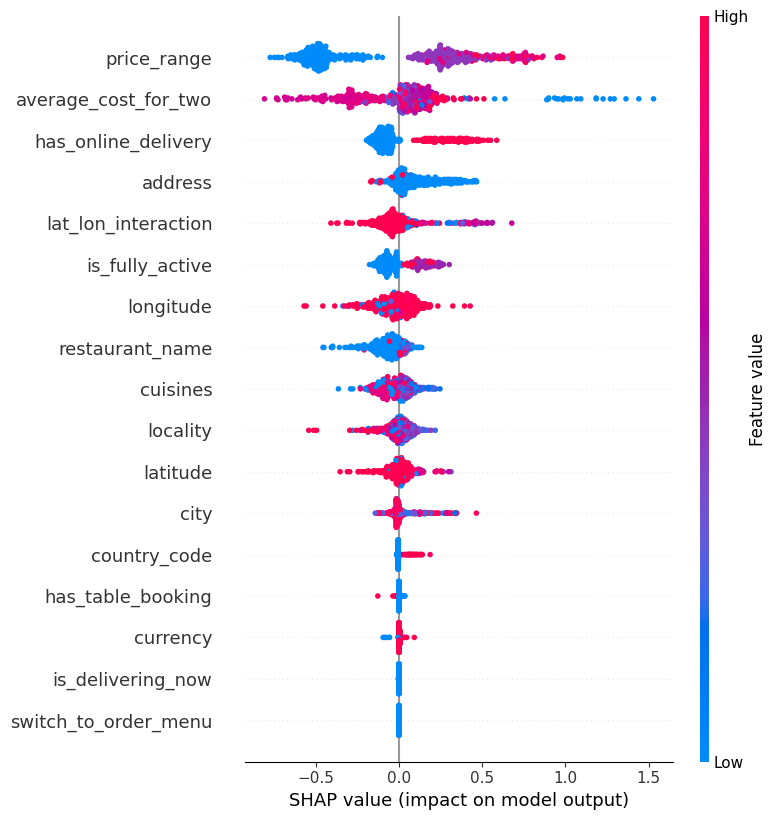

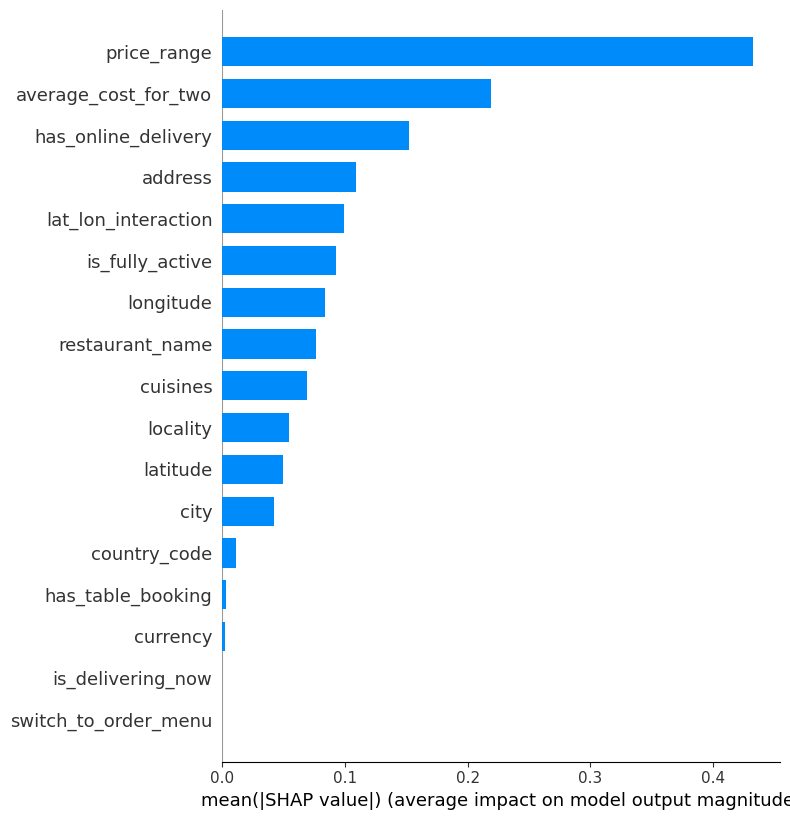

.values =
array([[-5.64492724e-02, -4.04218306e-03,  5.82359981e-03, ...,
        -4.67110168e-01, -7.00487402e-02,  2.58538767e-02],
       [-4.73701563e-02, -5.37564642e-03, -1.86161752e-02, ...,
         2.44371869e-01,  1.73020380e-01, -5.50130207e-02],
       [-1.43355809e-01, -5.24170229e-03, -1.54012281e-02, ...,
         2.20467614e-01, -5.76615906e-02, -3.70289178e-02],
       ...,
       [-8.95854671e-02, -4.35176226e-03,  6.17266613e-05, ...,
        -4.83733062e-01, -7.71745585e-02, -5.16221589e-02],
       [ 8.40481470e-03, -1.20233136e-02,  8.20305236e-02, ...,
         4.37803246e-01,  8.05381812e-02,  4.48406964e-01],
       [-9.18158116e-02, -7.82036740e-03, -4.15203657e-02, ...,
         3.62356150e-01,  1.10542925e-01, -8.26870980e-02]])

.base_values =
array([2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179,
       2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179,
       2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179, 2.64179,
       

In [30]:

trainer = Trainer(version='improved')

trainer.train(x_train_selected_cs, y_train, model_name='random_forest')

metrics_rf = trainer.evaluate(x_test_selected_cs, y_test)
print(metrics_rf)

trainer.save_model()
trainer.save_results(metrics_rf)
trainer.shap_explain(x_train_selected_cs, x_test_selected_cs)


# Training (Linear Regression)(Feature Importance)

{'model': 'linear_regression', 'version': 'improved', 'r2': -113.4783, 'mae': 15.3241, 'rmse': np.float64(16.142)}

📊 SHAP Summary — linear_regression


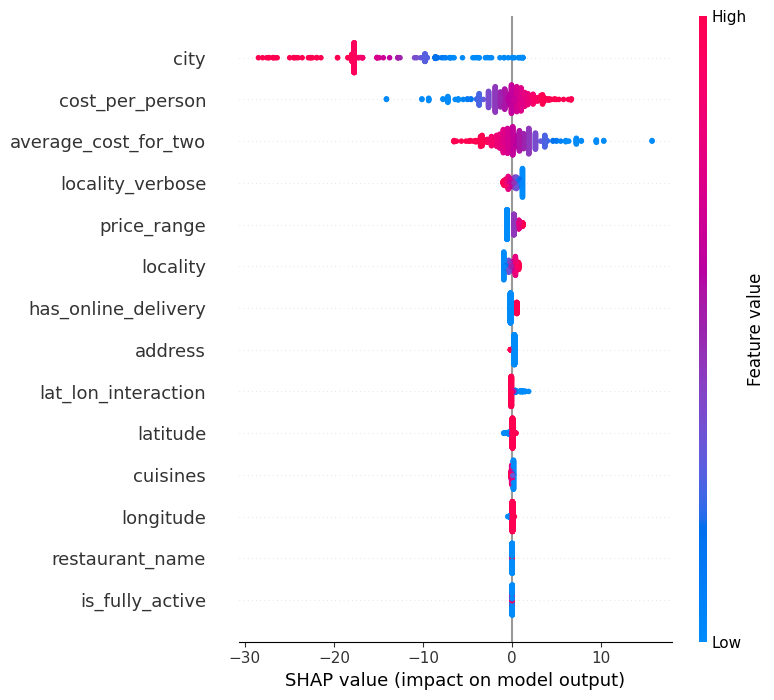

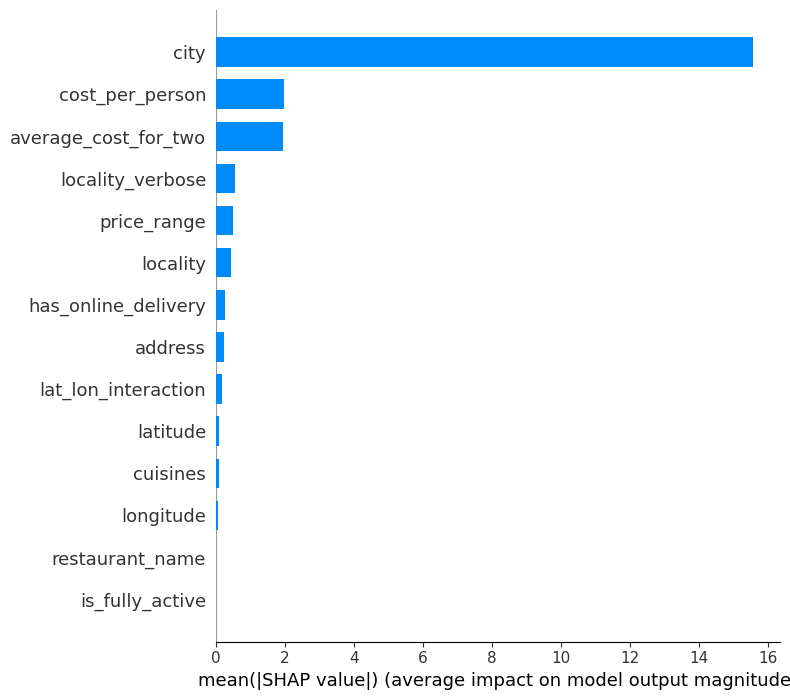

.values =
array([[-5.77994578e-01,  2.99984839e-02,  2.47311141e-01, ...,
        -1.81154475e-01,  2.32589056e-03, -1.77267732e+01],
       [ 1.97627615e-01,  2.99244547e-02,  2.47311141e-01, ...,
         5.15593504e-01, -2.59270339e-03, -9.78367769e+00],
       [ 1.97627615e-01,  3.04739283e-02,  2.47311141e-01, ...,
        -1.81154475e-01,  2.32589056e-03, -1.79603937e+01],
       ...,
       [-5.77994578e-01,  3.04357824e-02,  2.47311141e-01, ...,
        -1.81154475e-01,  2.32589056e-03, -8.61557541e+00],
       [ 7.47940320e-01,  2.03677778e-02,  2.47311141e-01, ...,
         5.15593504e-01, -9.09473091e-03, -1.67922914e+01],
       [ 7.47940320e-01,  3.01887263e-02,  2.47311141e-01, ...,
         5.15593504e-01, -9.09473091e-03, -1.77267732e+01]])

.base_values =
array([2.68117225, 2.68117225, 2.68117225, 2.68117225, 2.68117225,
       2.68117225, 2.68117225, 2.68117225, 2.68117225, 2.68117225,
       2.68117225, 2.68117225, 2.68117225, 2.68117225, 2.68117225,
       2.6811722

In [31]:

trainer = Trainer(version='improved')

trainer.train(x_train_selected_fi, y_train, model_name='linear_regression')

metrics_lr = trainer.evaluate(x_test_selected_fi, y_test)
print(metrics_lr)

trainer.save_model()
trainer.save_results(metrics_lr)
trainer.shap_explain(x_train_selected_fi, x_test_selected_fi)


# Training (Random Forest)(Feature Importance)

{'model': 'random_forest', 'version': 'improved', 'r2': 0.3228, 'mae': 0.9659, 'rmse': np.float64(1.2416)}


100%|===================| 498/500 [00:55<00:00]        


📊 SHAP Summary — random_forest


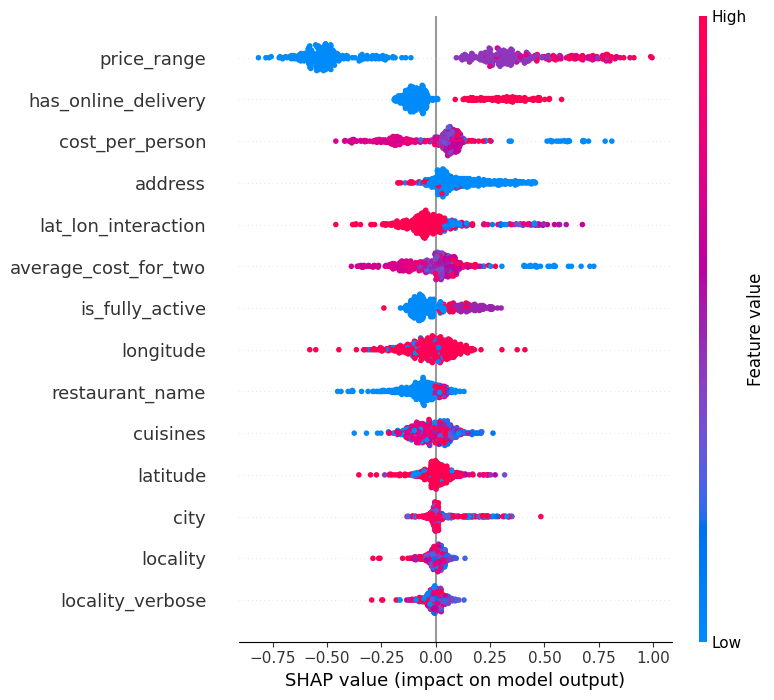

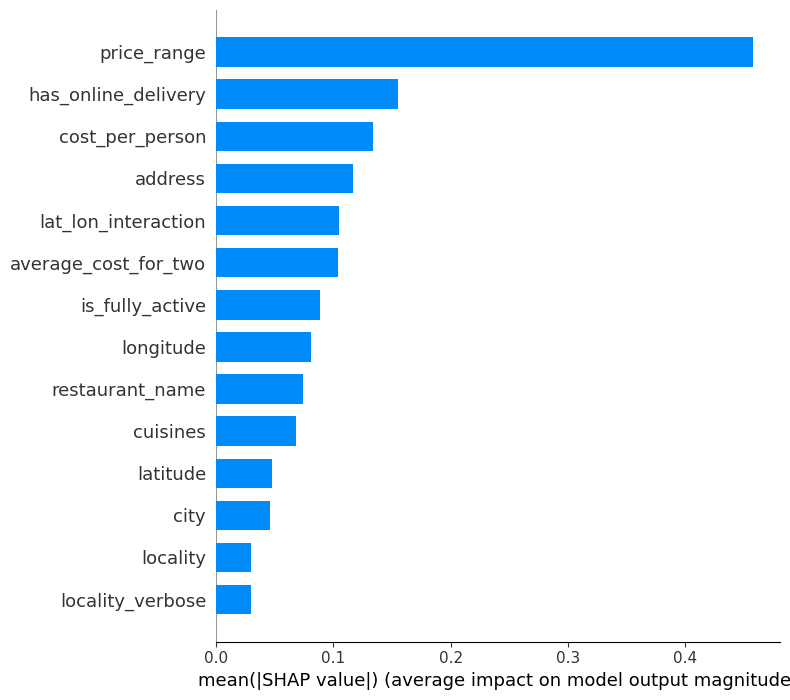

.values =
array([[-0.50853046,  0.03849868,  0.22058474, ..., -0.08687067,
        -0.06574166,  0.008855  ],
       [ 0.25519854,  0.05631224,  0.02524832, ...,  0.47890899,
         0.17860269, -0.01086797],
       [ 0.23913045, -0.06714765,  0.24253627, ..., -0.12820909,
        -0.05783668,  0.01381005],
       ...,
       [-0.5180354 ,  0.06534349,  0.13944919, ..., -0.1046904 ,
        -0.06916507,  0.00511244],
       [ 0.46486942, -0.01407358,  0.04107847, ...,  0.1589126 ,
         0.06494603,  0.10738276],
       [ 0.39015341,  0.13840149,  0.03226048, ...,  0.21064607,
         0.07536687, -0.03045624]])

.base_values =
array([2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388,
       2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388,
       2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388,
       2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388,
       2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388, 2.64388,
       2.64

In [32]:

trainer = Trainer(version='improved')

trainer.train(x_train_selected_fi, y_train, model_name='random_forest')

metrics_rf = trainer.evaluate(x_test_selected_fi, y_test)
print(metrics_rf)

trainer.save_model()
trainer.save_results(metrics_rf)
trainer.shap_explain(x_train_selected_fi, x_test_selected_fi)


# Training (Linear Regression)(RFE)

{'model': 'linear_regression', 'version': 'improved', 'r2': -120.6797, 'mae': 15.8034, 'rmse': np.float64(16.642)}

📊 SHAP Summary — linear_regression


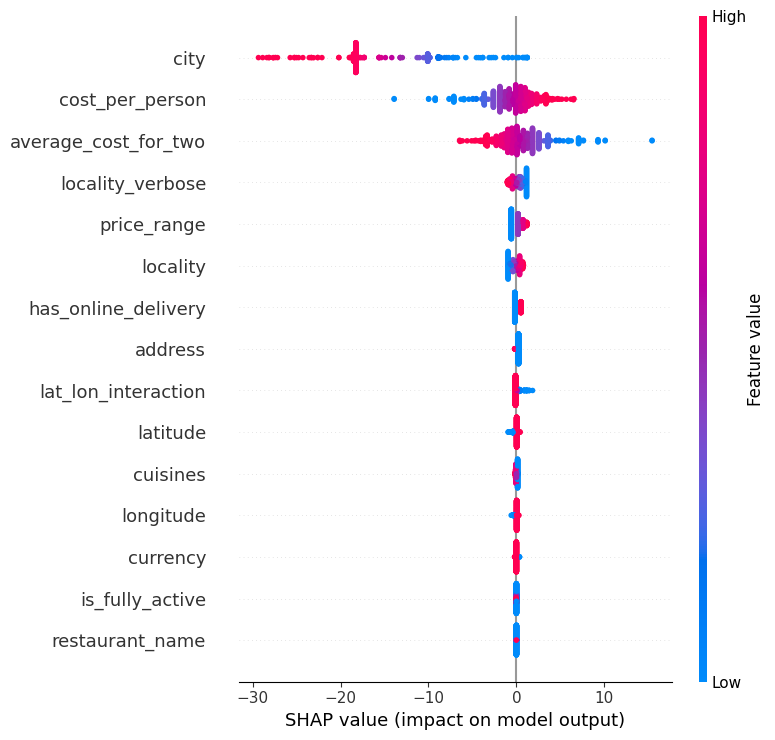

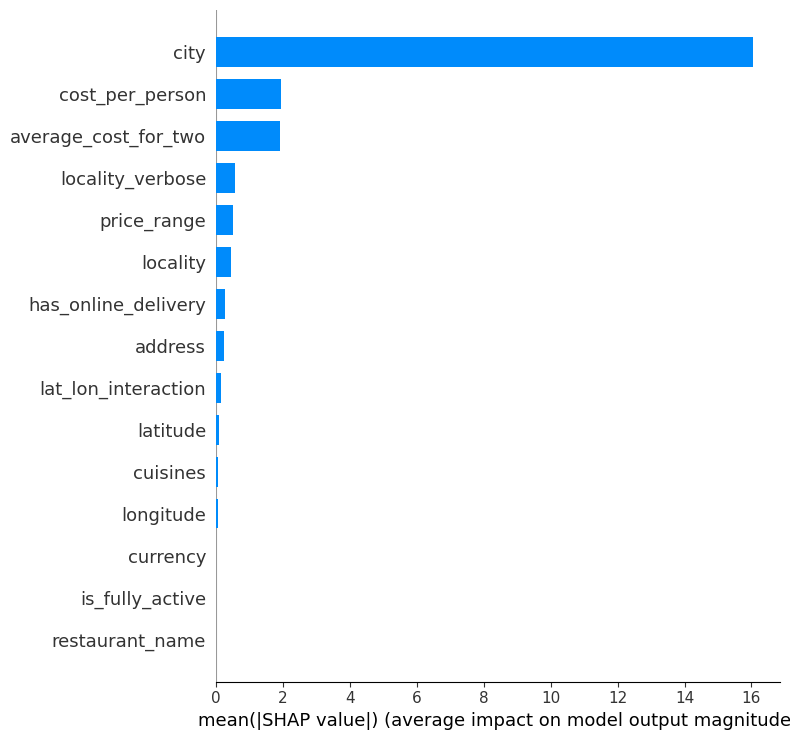

.values =
array([[-2.80476109e-03, -1.82734924e+01,  2.48210127e-01, ...,
        -4.19772328e-01,  4.82212787e-03, -9.88410360e-02],
       [ 2.79906873e-03, -1.00854204e+01,  2.48210127e-01, ...,
         1.38097715e+00, -5.37529473e-03, -9.56028787e-02],
       [ 2.79906873e-03, -1.85143181e+01,  2.48210127e-01, ...,
         7.53898477e-01,  4.82212787e-03, -9.90362756e-02],
       ...,
       [ 2.79906873e-03, -8.88129217e+00,  2.48210127e-01, ...,
        -1.29158501e+00,  4.82212787e-03, -9.58949573e-02],
       [-2.13272035e-03, -1.73101899e+01,  2.48210127e-01, ...,
         2.30918285e+00, -1.88555542e-02,  7.07242784e-02],
       [ 2.79906873e-03, -1.82734924e+01,  2.48210127e-01, ...,
         3.45058361e+00, -1.88555542e-02, -9.75559389e-02]])

.base_values =
array([2.68144333, 2.68144333, 2.68144333, 2.68144333, 2.68144333,
       2.68144333, 2.68144333, 2.68144333, 2.68144333, 2.68144333,
       2.68144333, 2.68144333, 2.68144333, 2.68144333, 2.68144333,
       2.6814433

In [33]:

trainer = Trainer(version='improved')

trainer.train(x_train_selected_rfe, y_train, model_name='linear_regression')

metrics_lr = trainer.evaluate(x_test_selected_rfe, y_test)
print(metrics_lr)

trainer.save_model()
trainer.save_results(metrics_lr)
trainer.shap_explain(x_train_selected_rfe, x_test_selected_rfe)


# Training (Random Forest)(RFE)

{'model': 'random_forest', 'version': 'improved', 'r2': 0.3211, 'mae': 0.9687, 'rmse': np.float64(1.2431)}


 98%|===================| 488/500 [00:45<00:01]        


📊 SHAP Summary — random_forest


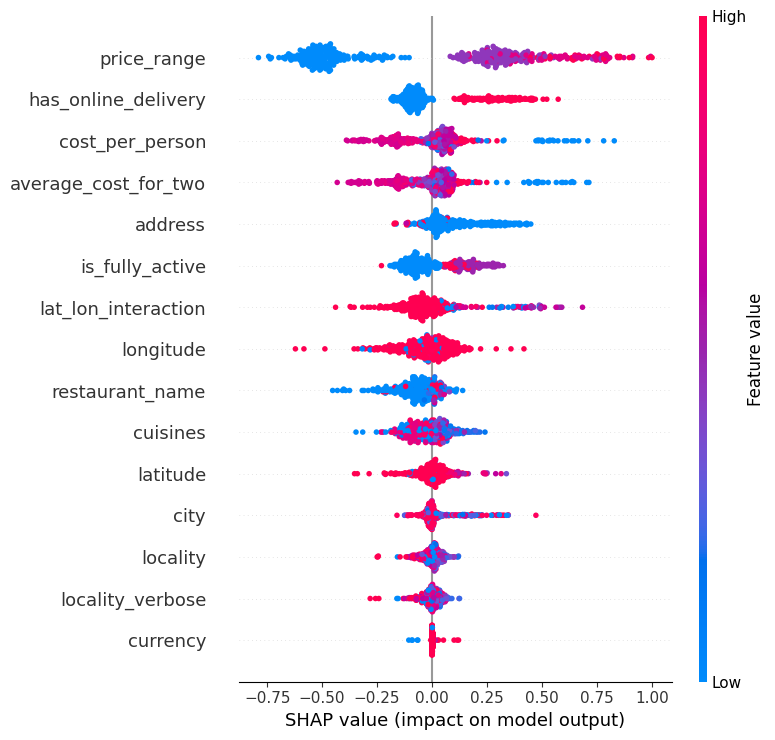

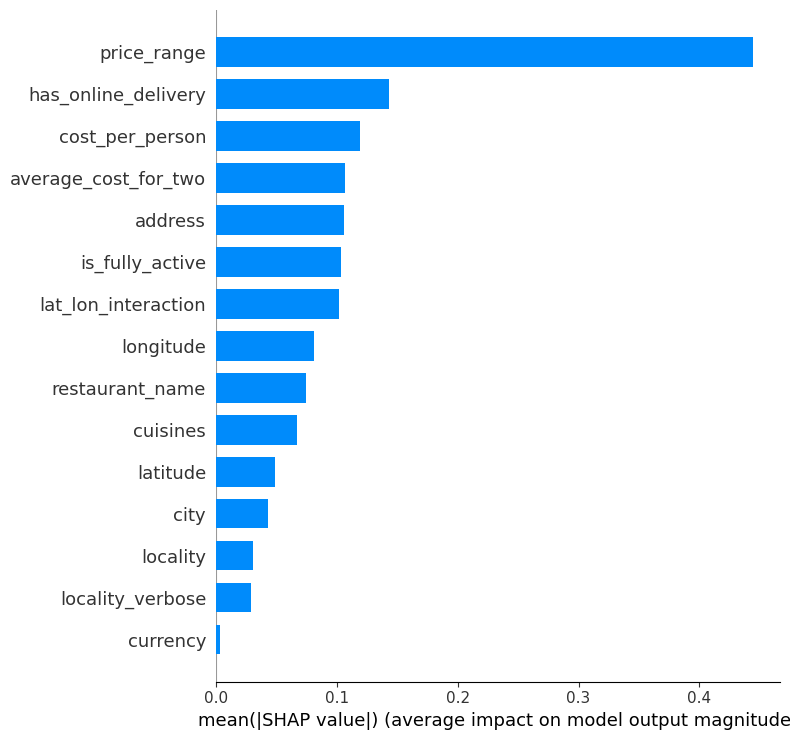

.values =
array([[-7.64762248e-02,  5.30324944e-03,  2.27024136e-01, ...,
         3.50014776e-02, -9.06646701e-02,  2.13074628e-02],
       [-4.37135586e-02, -2.07435218e-02,  1.96021500e-02, ...,
        -8.56925173e-02,  1.85488275e-01, -5.40732119e-02],
       [-1.39564824e-01, -3.97130663e-04,  1.92633789e-01, ...,
        -2.42048343e-01, -6.64519606e-02, -4.69473849e-02],
       ...,
       [-8.43268838e-02,  2.73036620e-03,  9.43398542e-02, ...,
         3.10152924e-02, -9.24796933e-02, -7.01558514e-02],
       [ 4.45745726e-03,  1.07949162e-01,  4.06675583e-02, ...,
         5.31477638e-03,  8.37292927e-02,  4.51968644e-01],
       [-8.70128252e-02, -3.61265876e-02,  3.37958425e-02, ...,
         1.29111596e-01,  1.05592620e-01, -1.03429243e-01]])

.base_values =
array([2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556,
       2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556,
       2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556, 2.64556,
       

In [34]:

trainer = Trainer(version='improved')

trainer.train(x_train_selected_rfe, y_train, model_name='random_forest')

metrics_rf = trainer.evaluate(x_test_selected_rfe, y_test)
print(metrics_rf)

trainer.save_model()
trainer.save_results(metrics_rf)
trainer.shap_explain(x_train_selected_rfe, x_test_selected_rfe)


# Save best model

In [29]:
trainer.save_best_model()

{'model': 'random_forest',
 'version': 'improved',
 'r2': 0.3228,
 'mae': 0.9659,
 'rmse': 1.2416}